#**Dependencies**

In [1]:
!pip install transformers dictdiffer

In [2]:
import zipfile
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import seaborn as sns

In [3]:
import torch
from torch.utils.data import Dataset
from transformers import ViTImageProcessor
import torch.nn as nn
from transformers import ViTModel
import torch.optim as optim
from torch.utils.data import DataLoader

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [ ]:
from google.colab import drive

## Connect Google Drive and Load Dataset

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


#**Dataset Loading**

In [ ]:
zip_path = '/content/drive/My Drive/ORBSCAN_Dataset.zip'
extraction_path = './ORBSCAN_Dataset'
csv_path = '/content/drive/MyDrive/clinical_data_and_labels.csv'

In [5]:
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_path}' successfully unzipped to '{extraction_path}'")

'/content/drive/My Drive/ORBSCAN_Dataset.zip' successfully unzipped to './ORBSCAN_Dataset'


Now, let's see what files are inside the unzipped directory. This will help us identify which file contains the data you want to explore.

In [6]:

if os.path.exists(extraction_path):
    print(f"Contents of '{extraction_path}':")
    for root, dirs, files in os.walk(extraction_path):
        for name in files:
            print(os.path.join(root, name))
        for name in dirs:
            print(os.path.join(root, name))
else:
    print(f"Extraction path '{extraction_path}' not found. Please ensure the zip file was unzipped correctly.")

Contents of './ORBSCAN_Dataset':
./ORBSCAN_Dataset/ORBSCAN_Dataset
./ORBSCAN_Dataset/ORBSCAN_Dataset/7GMFW
./ORBSCAN_Dataset/ORBSCAN_Dataset/GTQPQ
./ORBSCAN_Dataset/ORBSCAN_Dataset/54SR8
./ORBSCAN_Dataset/ORBSCAN_Dataset/U2H5A
./ORBSCAN_Dataset/ORBSCAN_Dataset/257QA
./ORBSCAN_Dataset/ORBSCAN_Dataset/23VJF
./ORBSCAN_Dataset/ORBSCAN_Dataset/TQJB3
./ORBSCAN_Dataset/ORBSCAN_Dataset/SJUGP
./ORBSCAN_Dataset/ORBSCAN_Dataset/XZE2J
./ORBSCAN_Dataset/ORBSCAN_Dataset/2XF3Y
./ORBSCAN_Dataset/ORBSCAN_Dataset/6H483
./ORBSCAN_Dataset/ORBSCAN_Dataset/Y7Q9W
./ORBSCAN_Dataset/ORBSCAN_Dataset/KCB1F
./ORBSCAN_Dataset/ORBSCAN_Dataset/J3E9K
./ORBSCAN_Dataset/ORBSCAN_Dataset/E5PAH
./ORBSCAN_Dataset/ORBSCAN_Dataset/MRJF8
./ORBSCAN_Dataset/ORBSCAN_Dataset/57Y9W
./ORBSCAN_Dataset/ORBSCAN_Dataset/HGPTR
./ORBSCAN_Dataset/ORBSCAN_Dataset/EB2F4
./ORBSCAN_Dataset/ORBSCAN_Dataset/BHVFH
./ORBSCAN_Dataset/ORBSCAN_Dataset/PPMXE
./ORBSCAN_Dataset/ORBSCAN_Dataset/VSDMC
./ORBSCAN_Dataset/ORBSCAN_Dataset/ZG1M3
./ORBSCAN_Dat

After running the previous cell, you will see a list of files and folders that were extracted. Please specify which file you would like to load into a pandas DataFrame (e.g., a `.csv` or `.xlsx` file).

### Load `clinical_data_and_labels.csv` and Initial Exploration

In [43]:

# Check if the file exists before attempting to load
if os.path.exists(csv_path):
    df_clinical = pd.read_csv(csv_path)
    print(f"Successfully loaded '{csv_path}'")
    print("\nFirst 5 rows of the dataset:")
    display(df_clinical.head())
    print("\nDataset Information:")
    df_clinical.info()
    print("\nDescriptive Statistics:")
    display(df_clinical.describe(include='all'))
else:
    print(f"Error: The file '{csv_path}' was not found. Please verify the exact path of the CSV file within your extracted dataset.")

Successfully loaded '/content/drive/MyDrive/clinical_data_and_labels.csv'

First 5 rows of the dataset:


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,pachy_thinnest_x,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold
0,63358,OS,41,m,-2.2,156,45.5,66,530,514,1.1,-0.9,-0.19,0.08,0,test,NaN
1,UAXDY,OS,30,f,-1.5,6,44.0,96,517,514,0.0,0.5,-0.29,-0.29,0,train,1.0
2,MF9GX,OD,23,m,-2.2,10,43.2,100,528,525,1.5,0.0,-0.25,2.21,0,train,2.0
3,XDKSU,OD,30,f,-2.0,28,46.5,118,541,532,-0.3,-0.5,-0.25,-0.28,0,train,5.0
4,DF14Z,OD,29,f,-2.2,139,41.6,49,544,534,-1.7,-0.5,-0.17,0.20,0,test,NaN



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1454 entries, 0 to 1453
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_code           1454 non-null   object 
 1   eye                    1454 non-null   object 
 2   age_years              1454 non-null   int64  
 3   gender                 1454 non-null   object 
 4   astig_value_D          1454 non-null   float64
 5   astig_axis_deg         1454 non-null   int64  
 6   kmax_value_D           1454 non-null   float64
 7   kmax_axis_deg          1454 non-null   int64  
 8   pachy_central_um       1454 non-null   int64  
 9   pachy_thinnest_um      1454 non-null   int64  
 10  pachy_thinnest_x       1454 non-null   float64
 11  pachy_thinnest_y       1454 non-null   float64
 12  asphericity_anterior   1454 non-null   float64
 13  asphericity_posterior  1454 non-null   float64
 14  label                  1454 non-nu

,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,pachy_thinnest_x,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold
count,1454,1454,1454.000000,1454,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454.000000,1454,1163.000000
unique,744,2,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,RCPWH,OD,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,NaN
freq,5,730,NaN,947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1163,NaN
mean,NaN,NaN,31.330124,NaN,-2.892600,91.593535,47.355227,91.985557,504.876204,484.453920,0.144498,-0.555227,-0.559319,-0.554367,0.388583,NaN,3.007739
std,NaN,NaN,7.803397,NaN,2.921828,66.664865,6.659720,35.698060,57.255310,67.931499,0.892529,0.584578,0.801683,0.783610,0.487596,NaN,1.413279
min,NaN,NaN,13.000000,NaN,-20.800000,1.000000,4.000000,1.000000,291.000000,251.000000,-2.500000,-2.500000,-3.790000,-4.230000,0.000000,NaN,1.000000
25%,NaN,NaN,26.000000,NaN,-4.075000,22.000000,43.500000,72.000000,472.000000,444.250000,-0.500000,-0.900000,-0.987500,-1.070000,0.000000,NaN,2.000000
50%,NaN,NaN,30.000000,NaN,-1.900000,90.000000,45.400000,91.000000,513.000000,498.000000,0.200000,-0.600000,-0.310000,-0.400000,0.000000,NaN,3.000000
75%,NaN,NaN,36.000000,NaN,-1.000000,162.000000,49.675000,112.000000,546.000000,536.000000,0.900000,-0.200000,-0.170000,-0.030000,1.000000,NaN,4.000000


In [44]:
df_clinical["patient_code"].duplicated().sum()

np.int64(710)

#**Data Overview**

In [45]:

print("Missing values per column:")
display(df_clinical.isnull().sum())

if 'gender' in df_clinical.columns:
    df_clinical['gender'] = df_clinical['gender'].astype('category')
    print("\n'gender' column converted to category type.")

if 'age_years' in df_clinical.columns:
    df_clinical['age_years'] = pd.to_numeric(df_clinical['age_years'], errors='coerce')
    print("\n'age_years' column converted to numeric type (non-numeric values coerced to NaN).")

    print(f"Missing values in 'age_years' after conversion: {df_clinical['age_years'].isnull().sum()}")

Missing values per column:


,0
patient_code,0
eye,0
age_years,0
gender,0
astig_value_D,0
astig_axis_deg,0
kmax_value_D,0
kmax_axis_deg,0
pachy_central_um,0
pachy_thinnest_um,0



'gender' column converted to category type.

'age_years' column converted to numeric type (non-numeric values coerced to NaN).
Missing values in 'age_years' after conversion: 0


### Data Analysis and Visualization

Average Age: 31.33 years


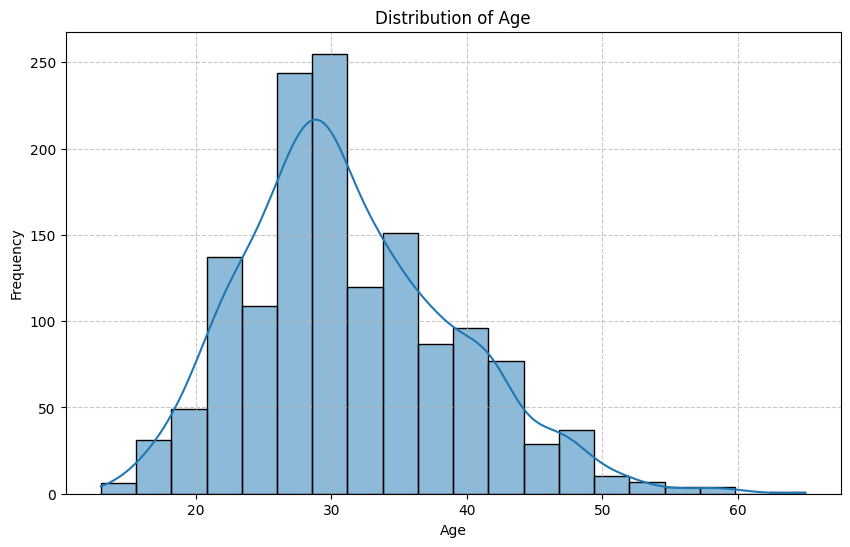

In [46]:

if 'age_years' in df_clinical.columns:
    average_age = df_clinical['age_years'].mean()
    print(f"Average Age: {average_age:.2f} years")

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(df_clinical['age_years'].dropna(), bins=20, kde=True, ax=ax)
    ax.set_title('Distribution of Age')
    ax.set_xlabel('Age')
    ax.set_ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print(" 'age_years' column not found for average age calculation and visualization.")


Gender Distribution:


,count
gender,
f,947
m,507


Male Ratio: 0.35
Female Ratio: 0.65


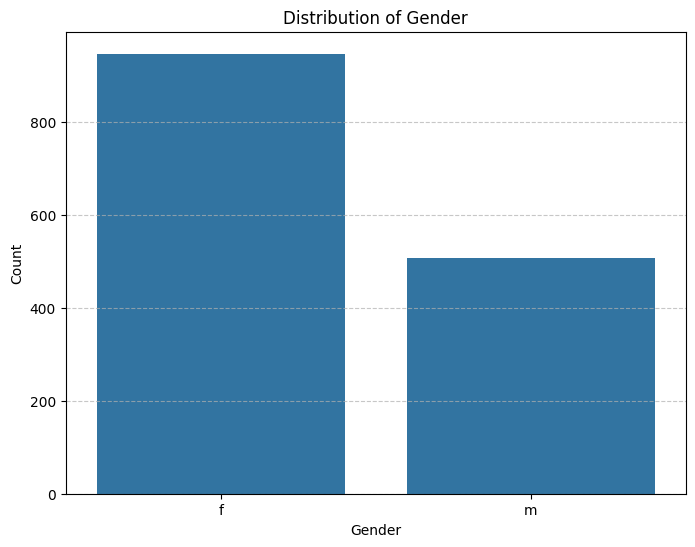

In [47]:

if 'gender' in df_clinical.columns:
    gender_counts = df_clinical['gender'].value_counts()
    print("\nGender Distribution:")
    display(gender_counts)

    if 'm' in gender_counts.index and 'f' in gender_counts.index:
        male_ratio = gender_counts['m'] / len(df_clinical['gender'].dropna())
        female_ratio = gender_counts['f'] / len(df_clinical['gender'].dropna())
        print(f"Male Ratio: {male_ratio:.2f}")
        print(f"Female Ratio: {female_ratio:.2f}")
    else:
        print("Could not calculate Male/Female ratio. Gender categories might be different than 'm'/'f'.")

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.countplot(x='gender', data=df_clinical, ax=ax)
    ax.set_title('Distribution of Gender')
    ax.set_xlabel('Gender')
    ax.set_ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print(" 'gender' column not found for ratio calculation and visualization.")

### Further Data Exploration

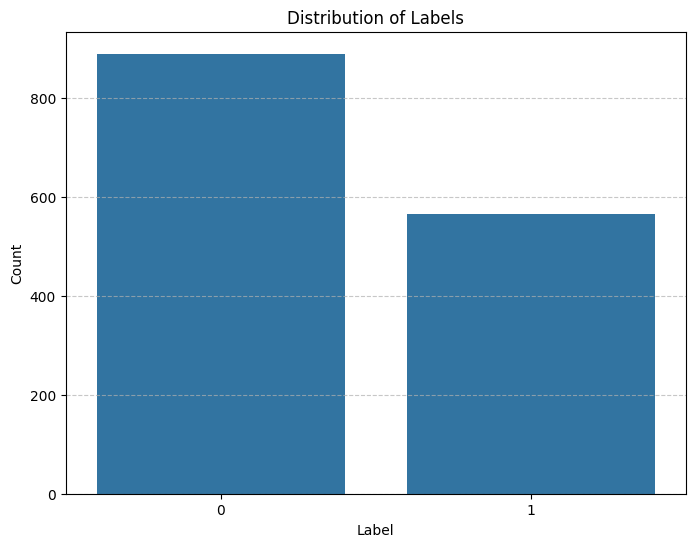

In [48]:

if 'label' in df_clinical.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='label', data=df_clinical)
    plt.title('Distribution of Labels')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("'label' column not found.")

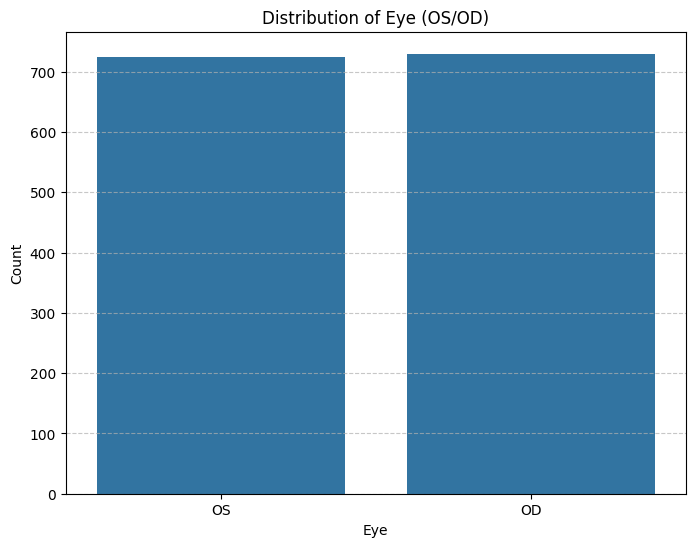

In [49]:

if 'eye' in df_clinical.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='eye', data=df_clinical)
    plt.title('Distribution of Eye (OS/OD)')
    plt.xlabel('Eye')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("'eye' column not found.")

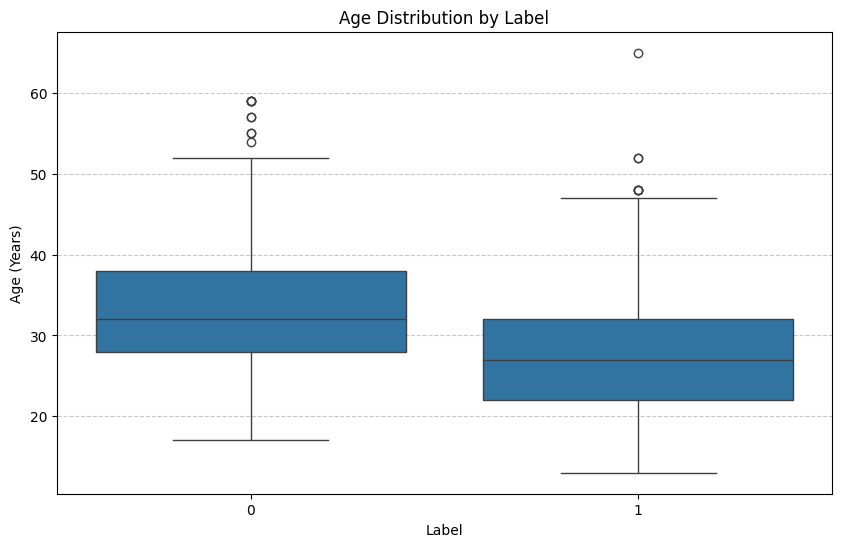

In [50]:

if 'age_years' in df_clinical.columns and 'label' in df_clinical.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='label', y='age_years', data=df_clinical)
    plt.title('Age Distribution by Label')
    plt.xlabel('Label')
    plt.ylabel('Age (Years)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("'age_years' or 'label' column not found for this analysis.")

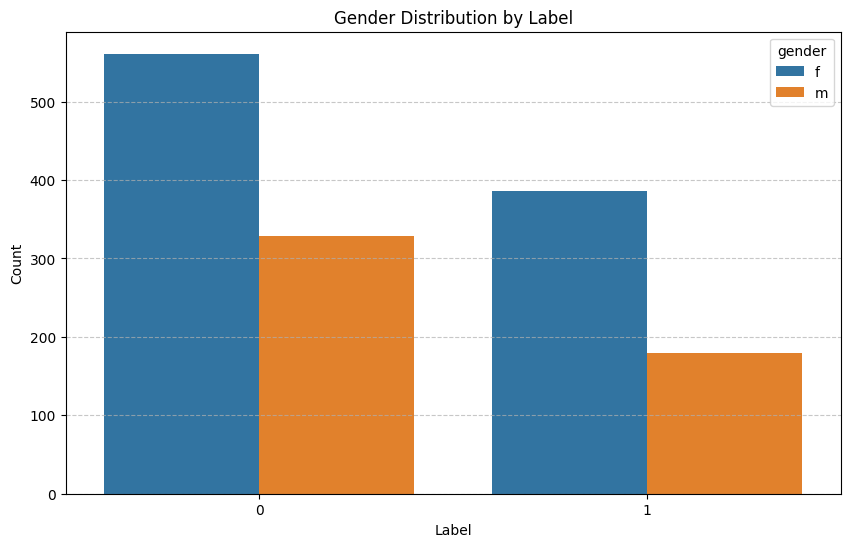

In [51]:

if 'gender' in df_clinical.columns and 'label' in df_clinical.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='label', hue='gender', data=df_clinical)
    plt.title('Gender Distribution by Label')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("'gender' or 'label' column not found for this analysis.")

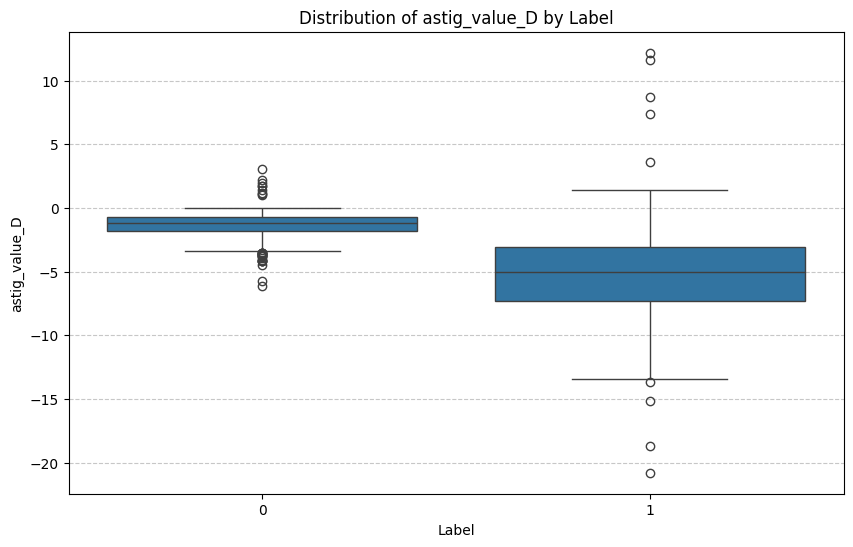

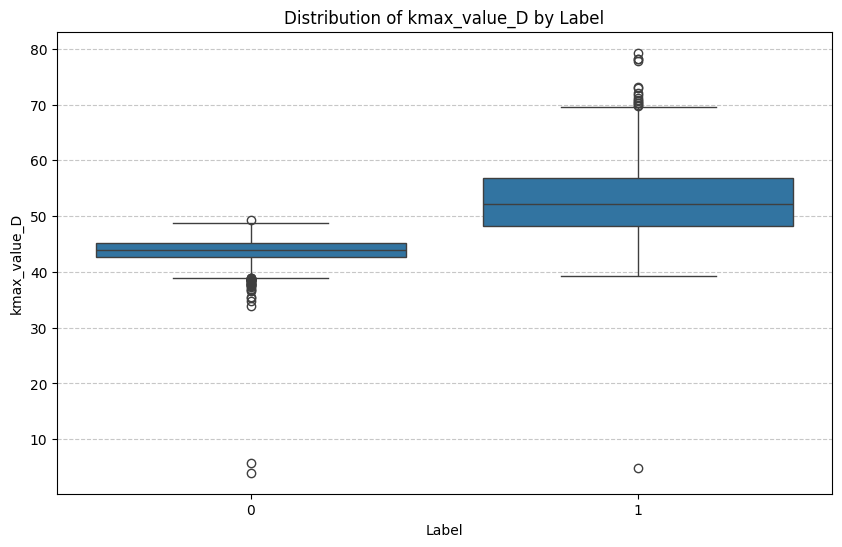

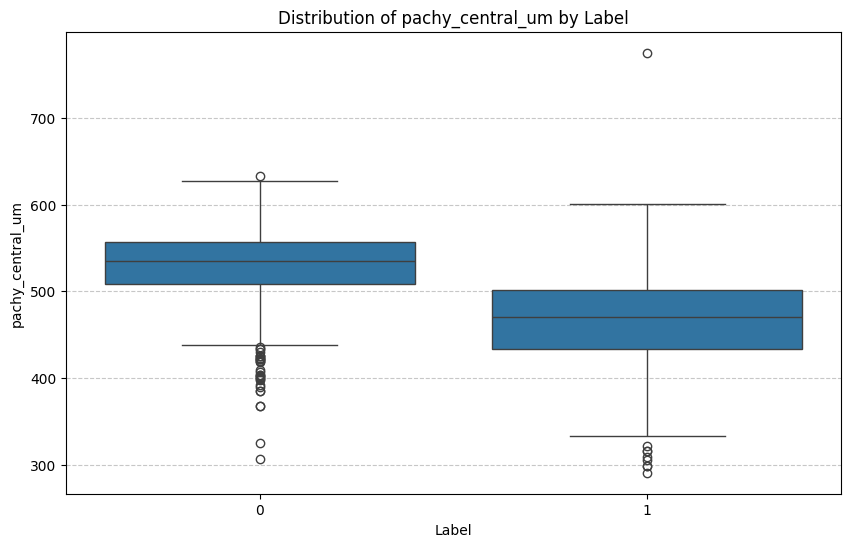

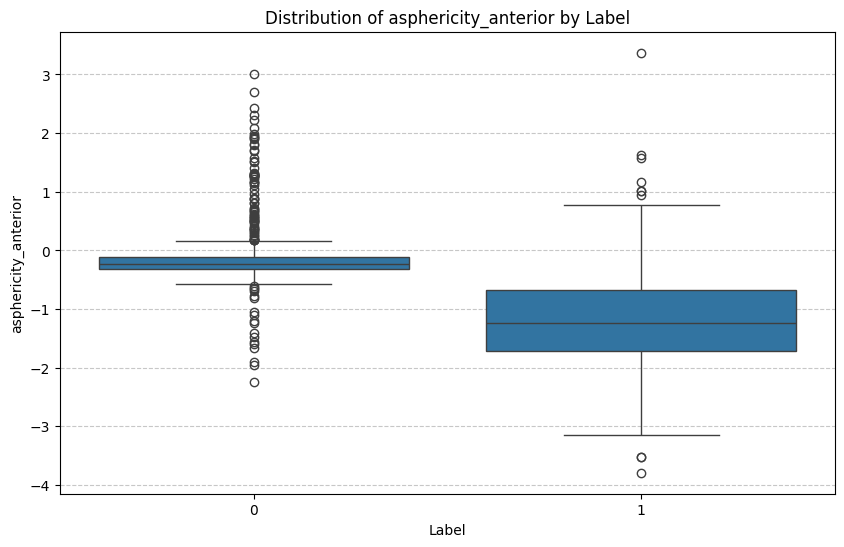

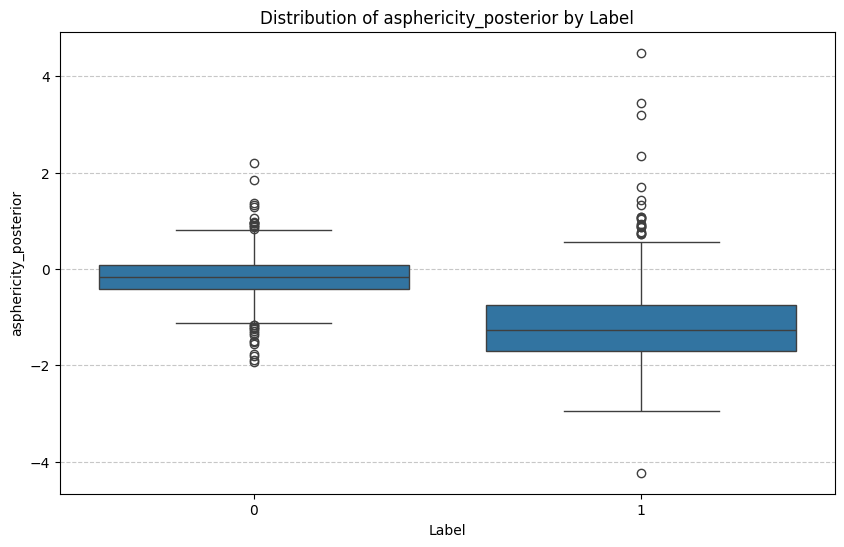

In [52]:

continuous_features = [
    'astig_value_D',
    'kmax_value_D',
    'pachy_central_um',
    'asphericity_anterior',
    'asphericity_posterior'
]

for feature in continuous_features:
    if feature in df_clinical.columns and 'label' in df_clinical.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='label', y=feature, data=df_clinical)
        plt.title(f'Distribution of {feature} by Label')
        plt.xlabel('Label')
        plt.ylabel(feature)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    else:
        print(f"'{feature}' or 'label' column not found for this analysis.")

#**Dataset Construction**



In [53]:

base_image_path = os.path.join(extraction_path, 'ORBSCAN_Dataset')

image_types = ['Anterior', 'Axial', 'Pachymetry', 'Posterior']

# Initialize new columns with NaN values
for img_type in image_types:
    df_clinical[f'{img_type}_map'] = np.nan

# Function to construct and verify file path
def get_image_path(row, img_type):
    patient_code = row['patient_code']
    eye = row['eye']
    # Construct the expected file name
    file_name = f"{patient_code}_{eye}_{img_type}.png"
    # Construct the full path
    full_path = os.path.join(base_image_path, patient_code, eye, file_name)
    # Check if the file exists
    if os.path.exists(full_path):
        return full_path
    else:
        return np.nan # Return NaN if file does not exist

# Populate the new columns
for img_type in image_types:
    df_clinical[f'{img_type}_map'] = df_clinical.apply(lambda row: get_image_path(row, img_type), axis=1)

print("Added image path columns to the clinical DataFrame. Displaying the first few rows with new columns:")
display(df_clinical.head())

Added image path columns to the clinical DataFrame. Displaying the first few rows with new columns:


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,...,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold,Anterior_map,Axial_map,Pachymetry_map,Posterior_map
0,63358,OS,41,m,-2.2,156,45.5,66,530,514,...,-0.9,-0.19,0.08,0,test,NaN,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...
1,UAXDY,OS,30,f,-1.5,6,44.0,96,517,514,...,0.5,-0.29,-0.29,0,train,1.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...
2,MF9GX,OD,23,m,-2.2,10,43.2,100,528,525,...,0.0,-0.25,2.21,0,train,2.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...
3,XDKSU,OD,30,f,-2.0,28,46.5,118,541,532,...,-0.5,-0.25,-0.28,0,train,5.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...
4,DF14Z,OD,29,f,-2.2,139,41.6,49,544,534,...,-0.5,-0.17,0.20,0,test,NaN,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...


In [54]:

image_columns = ['Anterior_map', 'Axial_map', 'Pachymetry_map', 'Posterior_map']

nan_image_paths = df_clinical[df_clinical[image_columns].isnull().any(axis=1)]

if not nan_image_paths.empty:
    print(f"Found {len(nan_image_paths)} rows with NaN values in image path columns:")
    display(nan_image_paths)
else:
    print("No rows found with NaN values in image path columns.")

Found 2 rows with NaN values in image path columns:


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,...,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold,Anterior_map,Axial_map,Pachymetry_map,Posterior_map
240,3E+132,OS,40,f,-1.7,6,45.8,96,534,526,...,-0.7,-0.06,-0.23,0,test,NaN,NaN,NaN,NaN,NaN
330,3E+132,OD,40,f,-1.6,169,45.8,79,531,525,...,-1.3,-0.20,-0.21,0,test,NaN,NaN,NaN,NaN,NaN


In [55]:
df_clinical.dropna(subset=image_columns, inplace=True)
print(f"Shape of df_clinical after dropping rows with NaN image paths: {df_clinical.shape}")
print("First 5 rows of df_clinical after dropping NaNs:")
display(df_clinical.head())

Shape of df_clinical after dropping rows with NaN image paths: (1452, 21)
First 5 rows of df_clinical after dropping NaNs:


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,...,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold,Anterior_map,Axial_map,Pachymetry_map,Posterior_map
0,63358,OS,41,m,-2.2,156,45.5,66,530,514,...,-0.9,-0.19,0.08,0,test,NaN,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...
1,UAXDY,OS,30,f,-1.5,6,44.0,96,517,514,...,0.5,-0.29,-0.29,0,train,1.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...
2,MF9GX,OD,23,m,-2.2,10,43.2,100,528,525,...,0.0,-0.25,2.21,0,train,2.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...
3,XDKSU,OD,30,f,-2.0,28,46.5,118,541,532,...,-0.5,-0.25,-0.28,0,train,5.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...
4,DF14Z,OD,29,f,-2.2,139,41.6,49,544,534,...,-0.5,-0.17,0.20,0,test,NaN,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...


In [56]:
nan_image_paths = df_clinical[df_clinical[image_columns].isnull().any(axis=1)]

if not nan_image_paths.empty:
    print(f"Found {len(nan_image_paths)} rows with NaN values in image path columns:")
    display(nan_image_paths)
else:
    print("No rows found with NaN values in image path columns.")

No rows found with NaN values in image path columns.


In [57]:
df_clinical.columns.unique()

Index(['patient_code', 'eye', 'age_years', 'gender', 'astig_value_D',
       'astig_axis_deg', 'kmax_value_D', 'kmax_axis_deg', 'pachy_central_um',
       'pachy_thinnest_um', 'pachy_thinnest_x', 'pachy_thinnest_y',
       'asphericity_anterior', 'asphericity_posterior', 'label', 'split_80_20',
       'fold', 'Anterior_map', 'Axial_map', 'Pachymetry_map', 'Posterior_map'],
      dtype='object')

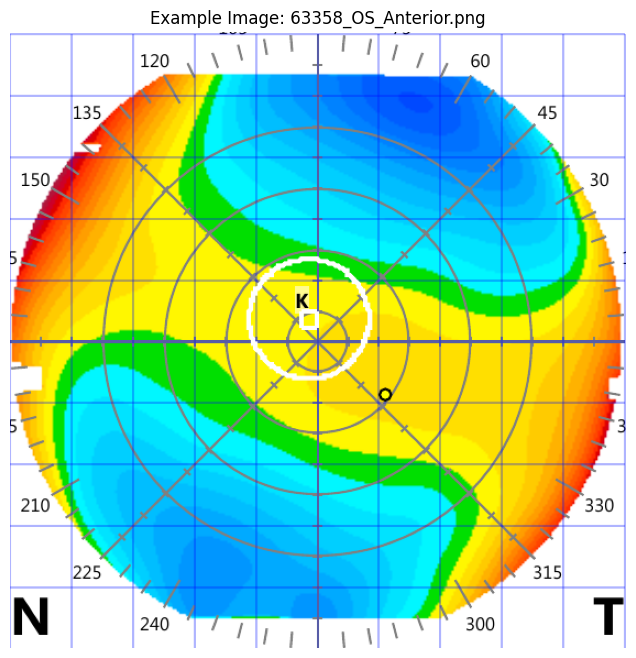

In [58]:


# Find the first non-null Anterior_map path
example_image_path = df_clinical['Anterior_map'].dropna().iloc[0]

if pd.notna(example_image_path):
    try:
        # Load the image
        img = Image.open(example_image_path)

        # Display the image
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.title(f"Example Image: {os.path.basename(example_image_path)}")
        plt.axis('off') # Hide axes ticks
        plt.show()
    except FileNotFoundError:
        print(f"Error: Image file not found at {example_image_path}")
    except Exception as e:
        print(f"An error occurred while loading or displaying the image: {e}")
else:
    print("No valid 'Anterior_map' image paths found in the DataFrame to display.")

Now, let's extract and merge the tabular data by adding columns for image file paths. We'll use the `patient_code` and `eye` columns to construct these paths.

In [59]:
df_clinical.head(4)

,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,...,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold,Anterior_map,Axial_map,Pachymetry_map,Posterior_map
0,63358,OS,41,m,-2.2,156,45.5,66,530,514,...,-0.9,-0.19,0.08,0,test,NaN,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...
1,UAXDY,OS,30,f,-1.5,6,44.0,96,517,514,...,0.5,-0.29,-0.29,0,train,1.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...
2,MF9GX,OD,23,m,-2.2,10,43.2,100,528,525,...,0.0,-0.25,2.21,0,train,2.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...
3,XDKSU,OD,30,f,-2.0,28,46.5,118,541,532,...,-0.5,-0.25,-0.28,0,train,5.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...


#**Making pytorch dataset**

In [60]:


class KeratoconusDataset(Dataset):
    def __init__(self, dataframe, tabular_cols, label_col, image_processor=None):
        """
        dataframe: Pre-scaled giant combined DataFrame
        tabular_cols: List of your selected tabular headers
        label_col: Target label header ('label')
        image_processor: Hugging Face image preprocessor
        """
        self.df = dataframe.reset_index(drop=True)
        self.tabular_features = self.df[tabular_cols].values.astype(np.float32)
        self.labels = self.df[label_col].values.astype(np.int64)

        # Mapping your specific map columns exactly
        self.map_cols = ['Anterior_map', 'Axial_map', 'Pachymetry_map', 'Posterior_map']

        if image_processor is None:
            # Use the base pre-trained ViT processor configuration
            self.image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
        else:
            self.image_processor = image_processor

    def __len__(self):
        return len(self.df)

    def _stitch_4_maps(self, idx):
        """Loads your 4 specific topography maps and stitches them into a 2x2 grid."""
        # Open your custom maps using your exact column headers
        img1 = Image.open(self.df.iloc[idx]['Anterior_map']).convert('RGB')
        img2 = Image.open(self.df.iloc[idx]['Axial_map']).convert('RGB')
        img3 = Image.open(self.df.iloc[idx]['Pachymetry_map']).convert('RGB')
        img4 = Image.open(self.df.iloc[idx]['Posterior_map']).convert('RGB')

        # Resize each quadrant to 112x112 so the combined canvas is exactly 224x224
        target_size = (112, 112)
        img1 = img1.resize(target_size)
        img2 = img2.resize(target_size)
        img3 = img3.resize(target_size)
        img4 = img4.resize(target_size)

        # Create a new blank RGB canvas
        grid_img = Image.new('RGB', (224, 224))

        # Paste maps into position
        grid_img.paste(img1, (0, 0))       # Top-Left: Anterior
        grid_img.paste(img2, (112, 0))     # Top-Right: Axial
        grid_img.paste(img3, (0, 112))     # Bottom-Left: Pachymetry
        grid_img.paste(img4, (112, 112))   # Bottom-Right: Posterior

        return grid_img

    def __getitem__(self, idx):
        # 1. Generate stitched canvas
        stitched_image = self._stitch_4_maps(idx)

        # 2. Automagically handle image normalization/scaling via Hugging Face
        processed_image = self.image_processor(images=stitched_image, return_tensors="pt")
        pixel_values = processed_image['pixel_values'].squeeze(0)

        # 3. Extract pre-scaled tabular features and label
        tabular_tensor = torch.tensor(self.tabular_features[idx], dtype=torch.float32)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)

        return pixel_values, tabular_tensor, label_tensor

In [61]:

image_columns = ['Anterior_map', 'Axial_map', 'Pachymetry_map', 'Posterior_map']

# The clean clinical data we feed to our Tabular MLP
tabular_columns = [
    'age_years',
    'gender',
    'astig_value_D',
    'astig_axis_deg',
    'pachy_thinnest_x',
    'pachy_thinnest_y'
]

label_column = 'label'

In [62]:
# label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clinical['gender'] = le.fit_transform(df_clinical['gender'])

In [63]:
df_clinical.head(4)

,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,...,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold,Anterior_map,Axial_map,Pachymetry_map,Posterior_map
0,63358,OS,41,1,-2.2,156,45.5,66,530,514,...,-0.9,-0.19,0.08,0,test,NaN,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...
1,UAXDY,OS,30,0,-1.5,6,44.0,96,517,514,...,0.5,-0.29,-0.29,0,train,1.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...
2,MF9GX,OD,23,1,-2.2,10,43.2,100,528,525,...,0.0,-0.25,2.21,0,train,2.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...
3,XDKSU,OD,30,0,-2.0,28,46.5,118,541,532,...,-0.5,-0.25,-0.28,0,train,5.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...


In [64]:
#Splitting Dataset with sourced splist before making python dataset
train_df = df_clinical[df_clinical['split_80_20'] == 'train'].copy()
test_df = df_clinical[df_clinical['split_80_20'] == 'test'].copy()
print(f"Train DataFrame shape: {train_df.shape}")
print(f"Test DataFrame shape: {test_df.shape}")

Train DataFrame shape: (1163, 21)
Test DataFrame shape: (289, 21)


In [65]:

print("Initializing StandardScaler...")
scaler = StandardScaler()

print("Fitting StandardScaler on training data and transforming both training and test data...")
# Fit and transform ONLY on the training data
train_df[tabular_columns] = scaler.fit_transform(train_df[tabular_columns])

# Transform the test data using the training data's averages
test_df[tabular_columns] = scaler.transform(test_df[tabular_columns])

print("Train DataFrame head after scaling:")
display(train_df.head())
print("Test DataFrame head after scaling:")
display(test_df.head())

Initializing StandardScaler...
Fitting StandardScaler on training data and transforming both training and test data...
Train DataFrame head after scaling:


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,...,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold,Anterior_map,Axial_map,Pachymetry_map,Posterior_map
1,UAXDY,OS,-0.172807,-0.746253,0.509217,-1.306620,44.0,96,517,514,...,1.897488,-0.29,-0.29,0,train,1.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...,./ORBSCAN_Dataset/ORBSCAN_Dataset/UAXDY/OS/UAX...
2,MF9GX,OD,-1.067160,1.340027,0.258298,-1.246132,43.2,100,528,525,...,1.015412,-0.25,2.21,0,train,2.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MF9GX/OD/MF9...
3,XDKSU,OD,-0.172807,-0.746253,0.329989,-0.973935,46.5,118,541,532,...,0.133335,-0.25,-0.28,0,train,5.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...,./ORBSCAN_Dataset/ORBSCAN_Dataset/XDKSU/OD/XDK...
5,3CD8B,OD,-0.428336,1.340027,-0.028467,-1.215888,46.2,102,547,537,...,-0.572326,-0.31,0.24,0,train,4.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/3CD8B/OD/3CD...,./ORBSCAN_Dataset/ORBSCAN_Dataset/3CD8B/OD/3CD...,./ORBSCAN_Dataset/ORBSCAN_Dataset/3CD8B/OD/3CD...,./ORBSCAN_Dataset/ORBSCAN_Dataset/3CD8B/OD/3CD...
6,2ZU4W,OS,-0.683866,-0.746253,0.294143,1.249005,37.4,85,524,615,...,1.368242,3.00,-0.29,0,train,1.0,./ORBSCAN_Dataset/ORBSCAN_Dataset/2ZU4W/OS/2ZU...,./ORBSCAN_Dataset/ORBSCAN_Dataset/2ZU4W/OS/2ZU...,./ORBSCAN_Dataset/ORBSCAN_Dataset/2ZU4W/OS/2ZU...,./ORBSCAN_Dataset/ORBSCAN_Dataset/2ZU4W/OS/2ZU...


Test DataFrame head after scaling:


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,...,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold,Anterior_map,Axial_map,Pachymetry_map,Posterior_map
0,63358,OS,1.232606,1.340027,0.258298,0.961687,45.5,66,530,514,...,-0.572326,-0.19,0.08,0,test,NaN,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...,./ORBSCAN_Dataset/ORBSCAN_Dataset/63358/OS/633...
4,DF14Z,OD,-0.300571,-0.746253,0.258298,0.704612,41.6,49,544,534,...,0.133335,-0.17,0.20,0,test,NaN,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...,./ORBSCAN_Dataset/ORBSCAN_Dataset/DF14Z/OD/DF1...
11,MWWCD,OS,1.871430,1.340027,0.903518,-0.973935,43.3,118,561,553,...,0.133335,-0.10,-0.10,0,test,NaN,./ORBSCAN_Dataset/ORBSCAN_Dataset/MWWCD/OS/MWW...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MWWCD/OS/MWW...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MWWCD/OS/MWW...,./ORBSCAN_Dataset/ORBSCAN_Dataset/MWWCD/OS/MWW...
27,3UGG3,OD,-0.428336,-0.746253,0.437526,-1.034423,43.4,114,598,588,...,2.779564,-0.30,-0.34,0,test,NaN,./ORBSCAN_Dataset/ORBSCAN_Dataset/3UGG3/OD/3UG...,./ORBSCAN_Dataset/ORBSCAN_Dataset/3UGG3/OD/3UG...,./ORBSCAN_Dataset/ORBSCAN_Dataset/3UGG3/OD/3UG...,./ORBSCAN_Dataset/ORBSCAN_Dataset/3UGG3/OD/3UG...
37,VN9ER,OD,-0.556101,-0.746253,0.688445,-1.155399,44.4,106,516,508,...,-1.983648,-0.30,0.17,0,test,NaN,./ORBSCAN_Dataset/ORBSCAN_Dataset/VN9ER/OD/VN9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/VN9ER/OD/VN9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/VN9ER/OD/VN9...,./ORBSCAN_Dataset/ORBSCAN_Dataset/VN9ER/OD/VN9...


In [68]:
train_dataset = KeratoconusDataset(dataframe=train_df, tabular_cols=tabular_columns, label_col='label')
test_dataset = KeratoconusDataset(dataframe=test_df, tabular_cols=tabular_columns, label_col='label')

In [69]:
from torch.utils.data import DataLoader
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True)

# Pull exactly one batch to inspect sizes
for pixel_values, tabular_tensor, label_tensor in test_loader:
    print("--- Sanity Check Passed ---")
    print(f"Stitched Image Batch Shape : {pixel_values.shape}")   # Should be [4, 3, 224, 224]
    print(f"Tabular Features Shape     : {tabular_tensor.shape}") # Should be [4, number_of_features]
    print(f"Labels Vector Shape        : {label_tensor.shape}")    # Should be [4]
    break

--- Sanity Check Passed ---
Stitched Image Batch Shape : torch.Size([4, 3, 224, 224])
Tabular Features Shape     : torch.Size([4, 6])
Labels Vector Shape        : torch.Size([4])


Stacked Image batch size: there are 4 images -> each image has 3 channels ( RGB ) -> each channel is of 224 X 224 Grid

#**MultiModal Arch Using pytorch**

In [70]:


class KeratoconusMultimodalNet(nn.Module):
    def __init__(self, tabular_input_dim, num_classes=2):
        super(KeratoconusMultimodalNet, self).__init__()

        # 1. Image Stream: Load a Pre-trained Vision Transformer
        # This model cuts our 224x224 stitched image into 16x16 patches automatically
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        image_feature_dim = self.vit.config.hidden_size # This is standardly 768 features

        # 2. Tabular Stream: Simple Multi-Layer Perceptron (MLP)
        # Processes our 6 clinical metrics down to a dense vector representation
        self.tabular_mlp = nn.Sequential(
            nn.Linear(tabular_input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),                 # Prevents overfitting on the small tabular vectors
            nn.Linear(64, 32),
            nn.ReLU()
        )
        tabular_feature_dim = 32

        # 3. Fusion & Final Classification Head
        # Glues the 768 image features and 32 tabular features together (Total: 800)
        combined_dim = image_feature_dim + tabular_feature_dim
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)       # Outputs 2 scores (e.g., [Normal, Keratoconus])
        )

    def forward(self, images, tabular_data):
        # Pass images through the ViT backbone
        vit_outputs = self.vit(pixel_values=images)

        # Extract the [CLS] token (Index 0). This is the summary token
        # that holds the self-attention features of the entire image canvas.
        image_features = vit_outputs.last_hidden_state[:, 0, :] # Shape: [Batch_size, 768]

        # Pass tabular features through our MLP
        tabular_features = self.tabular_mlp(tabular_data)       # Shape: [Batch_size, 32]

        # Concatenate (glue) the vectors side-by-side
        fused_features = torch.cat((image_features, tabular_features), dim=1) # Shape: [Batch_size, 800]

        # Generate prediction logits (raw scores)
        logits = self.classifier(fused_features)
        return logits

In [71]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using environment device: {device}")


num_tabular_features = len(tabular_columns)

# 3. Instantiate the model and push it to your GPU memory
model = KeratoconusMultimodalNet(tabular_input_dim=num_tabular_features, num_classes=2)
model = model.to(device)

# 4. Run a fast diagnostic pass using a temporary batch size of 2
from torch.utils.data import DataLoader
sanity_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

model.eval() # Put model into test/evaluation mode
with torch.no_grad():
    for imgs, tabs, labels in sanity_loader:
        # Move inputs to target device
        imgs, tabs = imgs.to(device), tabs.to(device)

        # Run forward prediction pass
        test_output = model(imgs, tabs)

        print("\n--- Model Validation Check Successful! ---")
        print(f"Output Matrix Shape: {test_output.shape}") # Should be [2, 2]
        break

Using environment device: cuda


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


--- Model Validation Check Successful! ---
Output Matrix Shape: torch.Size([2, 2])


#**Model Training**

In [72]:

# 1. Create real DataLoaders for training and testing
# (Adjust batch_size depending on your GPU memory; 16 or 32 is standard for ViTs)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. Separate parameters to assign different learning rates
optimizer = optim.AdamW([
    {'params': model.vit.parameters(), 'lr': 1e-5},               # Slow fine-tuning for ViT
    {'params': model.tabular_mlp.parameters(), 'lr': 1e-3},       # Faster learning for Tabular MLP
    {'params': model.classifier.parameters(), 'lr': 1e-3}         # Faster learning for Head Classifier
], weight_decay=0.01)

# 3. Define standard Cross-Entropy Loss for classification
criterion = nn.CrossEntropyLoss()

In [73]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    for imgs, tabs, labels in dataloader:
        # Move data to GPU
        imgs, tabs, labels = imgs.to(device), tabs.to(device), labels.to(device)

        # Zero out gradients from previous step
        optimizer.zero_grad()

        # Forward pass
        outputs = model(imgs, tabs)
        loss = criterion(outputs, labels)

        # Backward pass & weight update
        loss.backward()
        optimizer.step()

        # Track statistics
        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_preds += torch.sum(preds == labels.data)
        total_preds += labels.size(0)

    epoch_loss = running_loss / total_preds
    epoch_acc = correct_preds.double() / total_preds
    return epoch_loss, epoch_acc.item()

In [74]:

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for imgs, tabs, labels in dataloader:
            imgs, tabs, labels = imgs.to(device), tabs.to(device), labels.to(device)

            outputs = model(imgs, tabs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            probs = torch.softmax(outputs, dim=1)[:, 1] # Get probability of the positive class

            correct_preds += torch.sum(preds == labels.data)
            total_preds += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / total_preds
    epoch_acc = correct_preds.double() / total_preds

    return epoch_loss, epoch_acc.item(), np.array(all_labels), np.array(all_preds), np.array(all_probs)

Starting Local Centralized Training Simulation...
Epoch 1/5:
  [Train] Loss: 0.2634 | Acc: 90.46%
  [Valid] Loss: 0.0380 | Acc: 99.31%
Epoch 2/5:
  [Train] Loss: 0.0682 | Acc: 98.19%
  [Valid] Loss: 0.0420 | Acc: 97.92%
Epoch 3/5:
  [Train] Loss: 0.0316 | Acc: 99.05%
  [Valid] Loss: 0.0618 | Acc: 97.58%
Epoch 4/5:
  [Train] Loss: 0.0215 | Acc: 99.40%
  [Valid] Loss: 0.0344 | Acc: 98.96%
Epoch 5/5:
  [Train] Loss: 0.0045 | Acc: 100.00%
  [Valid] Loss: 0.0331 | Acc: 98.96%

--- Final Evaluation on Test Set (Last Epoch) ---
Precision (R1 Score): 0.9825
Recall: 0.9912
F1 Score: 0.9868
AUC: 0.9996


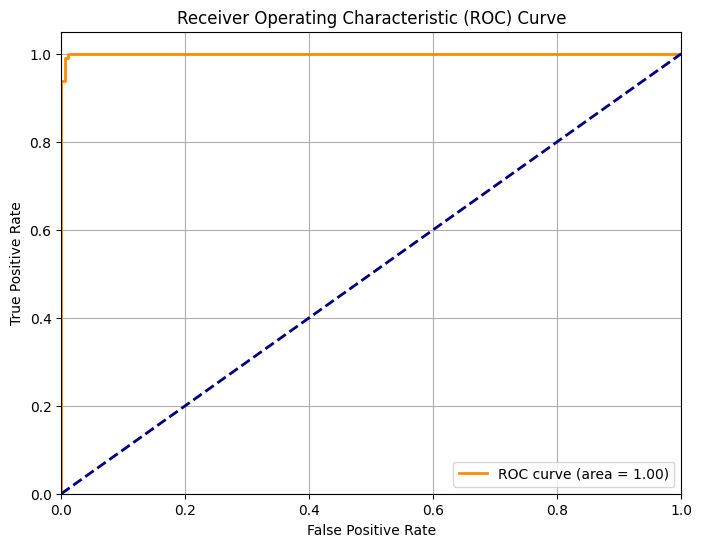

In [75]:


EPOCHS = 5

print("Starting Local Centralized Training Simulation...")

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Variables to store metrics from the last epoch for final evaluation
final_all_labels = []
final_all_preds = []
final_all_probs = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, current_labels, current_preds, current_probs = evaluate_model(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    final_all_labels = current_labels
    final_all_preds = current_preds
    final_all_probs = current_probs

    print(f"Epoch {epoch+1}/{EPOCHS}:")
    print(f"  [Train] Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
    print(f"  [Valid] Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}%")

print("\n--- Final Evaluation on Test Set (Last Epoch) ---")

# Calculate additional metrics on the last epoch's evaluation results
precision = precision_score(final_all_labels, final_all_preds)
recall = recall_score(final_all_labels, final_all_preds)
f1 = f1_score(final_all_labels, final_all_preds)
auc = roc_auc_score(final_all_labels, final_all_probs)

print(f"Precision (R1 Score): {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(final_all_labels, final_all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Training and Validation Metrics Over Epochs

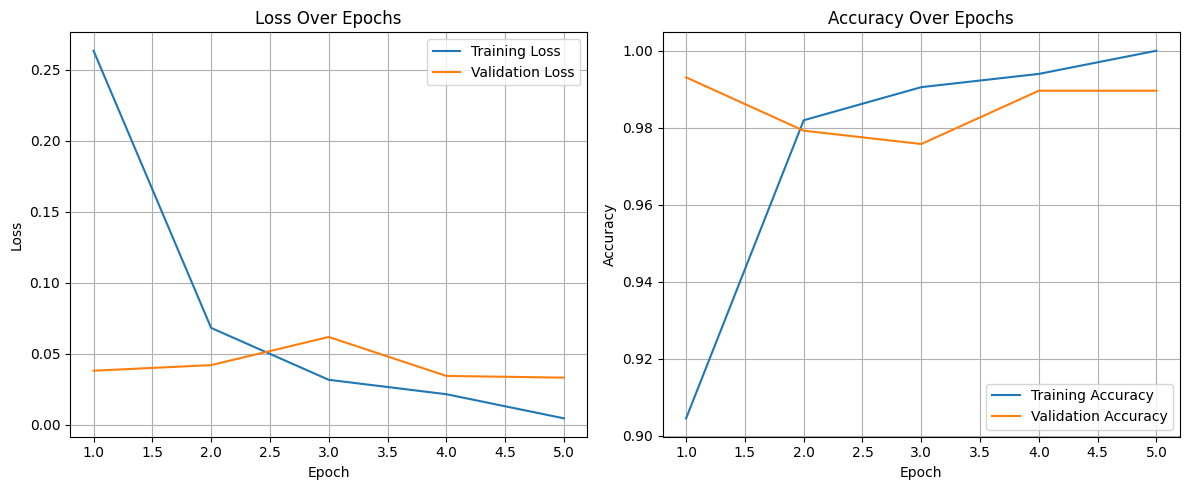

In [76]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label='Training Loss')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, EPOCHS + 1), val_accuracies, label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Confusion Matrix

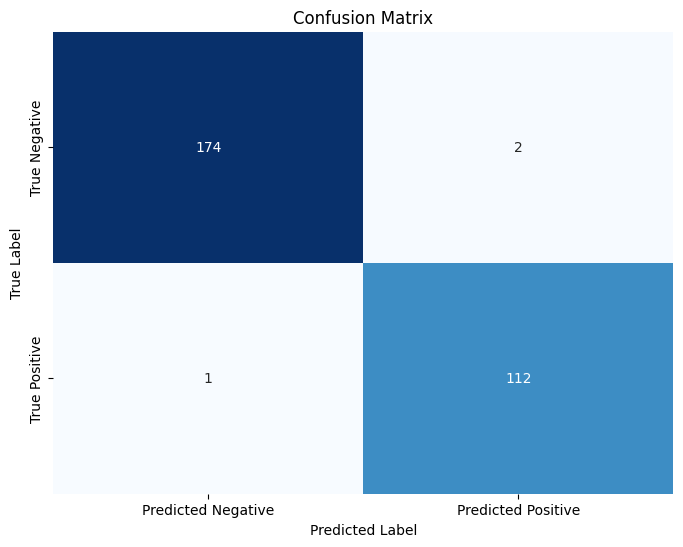

In [77]:


# Generate Confusion Matrix
cm = confusion_matrix(final_all_labels, final_all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['True Negative', 'True Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#**Exporting Model**

# Task
Make the multimodal Keratoconus detection model available as a production-ready service, highlighting the role of the API and security.

## Save Trained Model and Preprocessing Tools

### Subtask:
Save the trained `KeratoconusMultimodalNet` model to disk, along with the `StandardScaler` and `LabelEncoder` used for preprocessing, to Google Drive.


**Reasoning**:
The first instruction is to save the trained `model` object using `torch.save()`. I will create a path in Google Drive for the model and use `torch.save()`.



In [79]:
import torch
import pickle
import os

# Define the directory in Google Drive where models and preprocessing tools will be saved
save_dir = '/content/drive/MyDrive/keratoconus_model'
os.makedirs(save_dir, exist_ok=True)

# 1. Save the trained model
model_path = os.path.join(save_dir, 'keratoconus_multimodal_model.pt')
torch.save(model.state_dict(), model_path)
print(f"Trained model saved to: {model_path}")

Trained model saved to: /content/drive/MyDrive/keratoconus_model/keratoconus_multimodal_model.pt


**Reasoning**:
Now I will save the `StandardScaler` and `LabelEncoder` objects using `pickle.dump()`. I will create file paths within the `save_dir` for each.



In [80]:
scaler_path = os.path.join(save_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"StandardScaler saved to: {scaler_path}")

label_encoder_path = os.path.join(save_dir, 'label_encoder.pkl')
with open(label_encoder_path, 'wb') as f:
    pickle.dump(le, f)
print(f"LabelEncoder saved to: {label_encoder_path}")

StandardScaler saved to: /content/drive/MyDrive/keratoconus_model/scaler.pkl
LabelEncoder saved to: /content/drive/MyDrive/keratoconus_model/label_encoder.pkl


## Define Prediction Function

### Subtask:
Create a Python function that encapsulates the entire prediction pipeline: loading the saved model and preprocessing tools, taking raw image paths and tabular data as input, performing the necessary preprocessing (image stitching, tabular scaling, gender encoding), and then running inference with the loaded model to return predictions.


**Reasoning**:
I need to define the prediction function and load the saved model and preprocessing tools first. This step will load the necessary components for the prediction pipeline.



In [82]:
import torch
import pickle
import os
import pandas as pd
from PIL import Image
from transformers import ViTImageProcessor
import torch.nn as nn
from transformers import ViTModel

# Assuming KeratoconusMultimodalNet and ViTModel are defined in the environment
# Re-defining KeratoconusMultimodalNet for scope if not already globally available
class KeratoconatomeMultimodalNet(nn.Module):
    def __init__(self, tabular_input_dim, num_classes=2):
        super(KeratoconatomeMultimodalNet, self).__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        image_feature_dim = self.vit.config.hidden_size
        self.tabular_mlp = nn.Sequential(
            nn.Linear(tabular_input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        tabular_feature_dim = 32
        combined_dim = image_feature_dim + tabular_feature_dim
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, images, tabular_data):
        vit_outputs = self.vit(pixel_values=images)
        image_features = vit_outputs.last_hidden_state[:, 0, :]
        tabular_features = self.tabular_mlp(tabular_data)
        fused_features = torch.cat((image_features, tabular_features), dim=1)
        logits = self.classifier(fused_features)
        return logits

def _stitch_4_maps_for_prediction(anterior_map_path, axial_map_path, pachymetry_map_path, posterior_map_path):
    """Loads 4 topography maps from paths and stitches them into a 2x2 grid."""
    img1 = Image.open(anterior_map_path).convert('RGB')
    img2 = Image.open(axial_map_path).convert('RGB')
    img3 = Image.open(pachymetry_map_path).convert('RGB')
    img4 = Image.open(posterior_map_path).convert('RGB')

    target_size = (112, 112)
    img1 = img1.resize(target_size)
    img2 = img2.resize(target_size)
    img3 = img3.resize(target_size)
    img4 = img4.resize(target_size)

    grid_img = Image.new('RGB', (224, 224))

    grid_img.paste(img1, (0, 0))
    grid_img.paste(img2, (112, 0))
    grid_img.paste(img3, (0, 112))
    grid_img.paste(img4, (112, 112))

    return grid_img

def predict_keratoconus(anterior_map_path, axial_map_path, pachymetry_map_path, posterior_map_path,
                        age_years, gender, astig_value_D, astig_axis_deg, pachy_thinnest_x, pachy_thinnest_y):

    # Define the directory where models and preprocessing tools were saved
    save_dir = '/content/drive/MyDrive/keratoconus_model'

    # Determine device for inference
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Load the trained model
    num_tabular_features = 6 # Based on the training setup
    model = KeratoconatomeMultimodalNet(tabular_input_dim=num_tabular_features, num_classes=2)
    model_path = os.path.join(save_dir, 'keratoconus_multimodal_model.pt')
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval() # Set model to evaluation mode

    # 2. Load the StandardScaler and LabelEncoder
    scaler_path = os.path.join(save_dir, 'scaler.pkl')
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)

    label_encoder_path = os.path.join(save_dir, 'label_encoder.pkl')
    with open(label_encoder_path, 'rb') as f:
        label_encoder = pickle.load(f)

    # 3. Initialize ViTImageProcessor
    image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

    print("Model, scaler, label encoder, and image processor loaded successfully.")

    # 4. Preprocess Input Data
    # Image Preprocessing
    stitched_image = _stitch_4_maps_for_prediction(anterior_map_path, axial_map_path, pachymetry_map_path, posterior_map_path)
    processed_image = image_processor(images=stitched_image, return_tensors="pt")
    pixel_values = processed_image['pixel_values'].squeeze(0).unsqueeze(0) # Add batch dimension

    # Tabular Preprocessing
    # Encode gender
    try:
        gender_encoded = label_encoder.transform([gender])[0]
    except ValueError:
        print(f"Warning: Gender value '{gender}' not recognized by LabelEncoder. Ensure it's 'm' or 'f'.")
        # Handle unseen gender, e.g., by mapping to a default or raising an error
        # For now, let's assume valid gender input ('m' or 'f') is provided during actual use.
        # If 'm' or 'f' are the only classes, an unseen value would cause an error.
        # A more robust solution might involve checking label_encoder.classes_.
        if gender.lower() == 'm':
            gender_encoded = 1
        elif gender.lower() == 'f':
            gender_encoded = 0
        else:
            raise ValueError(f"Invalid gender value: {gender}. Must be 'm' or 'f'.")


    tabular_data_df = pd.DataFrame([{
        'age_years': age_years,
        'gender': gender_encoded,
        'astig_value_D': astig_value_D,
        'astig_axis_deg': astig_axis_deg,
        'pachy_thinnest_x': pachy_thinnest_x,
        'pachy_thinnest_y': pachy_thinnest_y
    }])

    # Scale tabular data
    # Ensure the order of columns for scaling matches the training data's `tabular_columns`
    tabular_columns_for_scaling = [
        'age_years',
        'gender',
        'astig_value_D',
        'astig_axis_deg',
        'pachy_thinnest_x',
        'pachy_thinnest_y'
    ]
    scaled_tabular_features = scaler.transform(tabular_data_df[tabular_columns_for_scaling])
    tabular_tensor = torch.tensor(scaled_tabular_features, dtype=torch.float32)

    # 5. Perform Inference
    with torch.no_grad():
        pixel_values = pixel_values.to(device)
        tabular_tensor = tabular_tensor.to(device)
        logits = model(pixel_values, tabular_tensor)
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        predicted_probability = probabilities[0][predicted_class].item()

    return predicted_class, predicted_probability

# Task
Make the multimodal Keratoconus detection model available as a production-ready service, highlighting the role of the API and security.

## Set Up API Endpoint (Conceptual)

### Subtask:
Outline the structure of a simple REST API endpoint for the Keratoconus detection model. Explain how this endpoint will receive input data, call the prediction function, and return the model's output. Also, explain how an API key can be integrated for authentication.


```markdown
## Set Up API Endpoint (Conceptual)

To make the `KeratoconusMultimodalNet` model available as a production-ready service, we would expose its prediction capability through a RESTful API. Below is a conceptual outline of such an endpoint, focusing on its structure, data flow, and security considerations.

### API Endpoint Definition

*   **Endpoint URL:** `/predict` (e.g., `https://your-service.com/predict`)
*   **HTTP Method:** `POST`
*   **Request Body Format:** `application/json`

### Expected Request Body Structure

The API endpoint would expect a JSON payload containing both the paths to the four image maps and the tabular clinical data for a single patient eye.

```json
{
    "api_key": "YOUR_API_KEY",
    "data": {
        "anterior_map_path": "path/to/anterior_map.png",
        "axial_map_path": "path/to/axial_map.png",
        "pachymetry_map_path": "path/to/pachymetry_map.png",
        "posterior_map_path": "path/to/posterior_map.png",
        "age_years": 35,
        "gender": "f",
        "astig_value_D": -1.75,
        "astig_axis_deg": 90,
        "pachy_thinnest_x": 0.2,
        "pachy_thinnest_y": -0.1
    }
}
```

### Internal Flow of the API Endpoint

1.  **Receive Request:** The API endpoint receives the `POST` request with the JSON payload.
2.  **API Key Validation:** The `api_key` from the request header or body is extracted and validated against a list of authorized keys or an authentication service. If the key is invalid or missing, an `HTTP 401 Unauthorized` response is returned.
3.  **Data Extraction:** The image paths and tabular data are extracted from the `data` field of the JSON body.
4.  **Call Prediction Function:** The extracted data is passed to the `predict_keratoconus` function (defined in the previous step).
    *   Inside `predict_keratoconus`, the model and preprocessing tools are loaded (if not already cached).
    *   Images are loaded, stitched, and preprocessed.
    *   Tabular data is encoded and scaled.
    *   Inference is performed by the `KeratoconusMultimodalNet` model.
    *   The function returns the predicted class and its probability.
5.  **Format Response:** The prediction results (e.g., `predicted_class` and `predicted_probability`) are formatted into a JSON response.
6.  **Send Response:** An `HTTP 200 OK` response with the JSON results is sent back to the client.

### Expected Response Body Structure

```json
{
    "prediction": {
        "class": 0, // 0 for Normal, 1 for Keratoconus
        "probability": 0.9876
    },
    "message": "Prediction successful"
}
```

### Security: API Key Integration

API keys serve as a simple yet effective authentication mechanism for internal or controlled access to the service:

*   **Issuance:** API keys would be generated and securely distributed to authorized clients.
*   **Validation:** Upon receiving a request, the API gateway or the Flask/FastAPI application itself would check the provided `api_key`.
    *   If the key is present in the request (e.g., in the `Authorization` header as `X-API-Key: YOUR_API_KEY` or in the request body as shown above) and matches a pre-configured valid key, the request proceeds.
    *   If the key is missing, invalid, or expired, the API rejects the request with an appropriate error message and an `HTTP 401 Unauthorized` status code.
*   **Benefits:** This prevents unauthorized access, allows for basic usage tracking, and enables revocation of access for specific clients if needed.
*   **Limitations:** API keys are typically transmitted as plaintext and should be considered less secure than token-based authentication (like OAuth2) for public-facing or high-security applications. For many internal or controlled microservices, they offer a good balance of security and simplicity.
```

## Consider Deployment Environment

### Subtask:
Discuss potential deployment environments like cloud functions (e.g., Google Cloud Functions, AWS Lambda), containerized services (e.g., Docker with Kubernetes), or dedicated ML deployment platforms. Explain how these platforms handle scaling and resource management.


```markdown
## Consider Deployment Environment

Deploying a multimodal Keratoconus detection model as a production-ready service requires careful consideration of the deployment environment. The choice impacts scalability, resource management, cost-efficiency, and operational complexity. Here, we discuss three primary approaches:

### 1. Cloud Functions (e.g., Google Cloud Functions, AWS Lambda, Azure Functions)

*   **Characteristics:** Serverless compute services that allow you to run code without provisioning or managing servers. They are event-driven, scaling automatically in response to demand.
*   **Scalability:** Highly scalable. They can instantly scale up to handle thousands of concurrent requests and scale down to zero when not in use, making them cost-effective for infrequent or bursty workloads.
*   **Resource Management:** Fully managed by the cloud provider. Users only pay for the compute time consumed. Resource allocation (CPU, memory) is configured per function.
*   **Suitability for Multimodal AI:**
    *   **Benefits:** Excellent for sporadic inference requests where latency is not extremely critical. Pay-per-execution model can be very cost-effective. Easy to integrate with other cloud services.
    *   **Drawbacks:** Cold starts can be a concern for models with large memory footprints (like ViT), as the environment needs to load the model into memory for the first request. Max execution time limits might be an issue for very complex or long-running inference tasks. Managing multiple dependencies for a complex multimodal model can sometimes be tricky in a serverless environment (e.g., specific PyTorch versions, Hugging Face transformers).

### 2. Containerized Services (e.g., Docker with Kubernetes, AWS ECS, Google Kubernetes Engine)

*   **Characteristics:** Applications are packaged into lightweight, portable, and self-sufficient containers (e.g., Docker images). Kubernetes (K8s) is an open-source system for automating deployment, scaling, and management of containerized applications.
*   **Scalability:** Highly scalable and flexible. Kubernetes can automatically scale the number of container instances based on CPU utilization, memory, or custom metrics. Horizontal Pod Autoscalers (HPAs) and Cluster Autoscalers manage this dynamically.
*   **Resource Management:** Provides fine-grained control over resource allocation (CPU, memory, GPU) for each container. Users manage the underlying infrastructure (VMs) or use managed Kubernetes services where the control plane is handled by the cloud provider. This allows for dedicated GPU resources for ML models.
*   **Suitability for Multimodal AI:**
    *   **Benefits:** Ideal for complex, resource-intensive models that benefit from dedicated hardware (e.g., GPUs). Solves dependency management issues by bundling everything into a container. Offers consistent environments from development to production. Provides robust monitoring, logging, and self-healing capabilities.
    *   **Drawbacks:** Higher operational overhead and complexity compared to serverless functions. Requires expertise in Docker and Kubernetes. Can be more expensive if not managed efficiently, as you often pay for provisioned resources even when idle.

### 3. Dedicated ML Deployment Platforms (e.g., Google Cloud AI Platform, AWS SageMaker, Azure Machine Learning)

*   **Characteristics:** End-to-end platforms specifically designed for building, training, and deploying machine learning models. They abstract away much of the underlying infrastructure complexity.
*   **Scalability:** Built-in autoscaling features tailored for ML workloads. They can scale endpoint capacity based on request load and also manage scaling for batch predictions.
*   **Resource Management:** Fully managed by the platform. They provide specialized compute instances (including GPU options) optimized for ML inference. Often include features like model versioning, A/B testing, and canary deployments.
*   **Suitability for Multimodal AI:**
    *   **Benefits:** Offers the easiest path to production for ML models, handling infrastructure, scaling, and monitoring with minimal user intervention. Provides MLOps features crucial for managing model lifecycle. Often integrate well with other services within the same cloud ecosystem. Excellent for models requiring GPUs for inference.
    *   **Drawbacks:** Can be vendor-locked to a specific cloud provider. May have higher costs compared to self-managed containerized solutions if not optimized. Less flexibility and control over the underlying infrastructure compared to raw Kubernetes.

### Recommendation for Keratoconus Multimodal Detection Model:

For the multimodal Keratoconus detection model, which likely benefits from GPU acceleration and has a non-trivial memory footprint (due to the ViT component), a **containerized service (Docker with Kubernetes)** or a **dedicated ML deployment platform** would be the most suitable choices.

*   **Dedicated ML Platform (e.g., SageMaker, AI Platform):** This is generally the most straightforward and recommended approach for putting ML models into production, especially if MLOps capabilities (monitoring, versioning, easy retraining) are a priority and a managed service aligns with the team's skillset. It handles scaling and resource management (including GPUs) optimally for ML inference.

*   **Containerized Service (Kubernetes):** If more control over the infrastructure, custom environments, or multi-cloud deployment is desired, a containerized approach with Kubernetes offers immense flexibility and scalability. It allows for precise resource allocation, including GPU attachment to pods, to ensure efficient model serving and minimize latency associated with model loading.

Cloud Functions might be considered for a lighter, less resource-intensive model or if the inference process could be significantly optimized to fit within their constraints (e.g., by using a smaller model or highly optimized image processing). However, for this multimodal model involving a ViT backbone, the latter two options provide a more robust and performant production environment.
```

## Final Task

### Subtask:
Summarize the steps required to make the multimodal Keratoconus detection model available as a production-ready service, highlighting the role of the API and security.
